In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df=pd.read_csv("forest_fire_dataset_cleaned.csv")
df = df.drop(['day', 'month', 'year'], axis=1)

In [3]:
df["Classes"] = np.where(df["Classes"].str.contains("not"),0, 1)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  243 non-null    int64  
 1   RH           243 non-null    int64  
 2   Ws           243 non-null    int64  
 3   Rain         243 non-null    float64
 4   FFMC         243 non-null    float64
 5   DMC          243 non-null    float64
 6   DC           243 non-null    float64
 7   ISI          243 non-null    float64
 8   BUI          243 non-null    float64
 9   FWI          243 non-null    float64
 10  Classes      243 non-null    int64  
 11  Region       243 non-null    int64  
dtypes: float64(7), int64(5)
memory usage: 22.9 KB


In [5]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [6]:
# Independent and Dependent
X = df.drop("FWI",axis=1)
y = df["FWI"]

In [7]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [8]:
# Train/Test split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.25,random_state=23)

In [10]:
X_train.shape, X_test.shape

((182, 11), (61, 11))

In [11]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.660341,-0.283116,-0.318560,0.692966,0.462077,0.333289,0.612724,0.428393,0.511902,0.327961
RH,-0.660341,1.000000,0.266720,0.232825,-0.627611,-0.360693,-0.167639,-0.680750,-0.299635,-0.435774,-0.467454
Ws,-0.283116,0.266720,1.000000,0.146309,-0.124295,0.038133,0.114276,0.007881,0.069373,-0.052849,-0.261802
Rain,-0.318560,0.232825,0.146309,1.000000,-0.555787,-0.305372,-0.309095,-0.360759,-0.312724,-0.387598,-0.029514
FFMC,0.692966,-0.627611,-0.124295,-0.555787,1.000000,0.614962,0.502234,0.741444,0.592986,0.771525,0.282539
DMC,0.462077,-0.360693,0.038133,-0.305372,0.614962,1.000000,0.884854,0.677389,0.984411,0.622708,0.181701
DC,0.333289,-0.167639,0.114276,-0.309095,0.502234,0.884854,1.000000,0.501378,0.951105,0.522806,-0.109327
ISI,0.612724,-0.680750,0.007881,-0.360759,0.741444,0.677389,0.501378,1.000000,0.630070,0.750613,0.303760
BUI,0.428393,-0.299635,0.069373,-0.312724,0.592986,0.984411,0.951105,0.630070,1.000000,0.606180,0.075005
Classes,0.511902,-0.435774,-0.052849,-0.387598,0.771525,0.622708,0.522806,0.750613,0.606180,1.000000,0.214731


<Axes: >

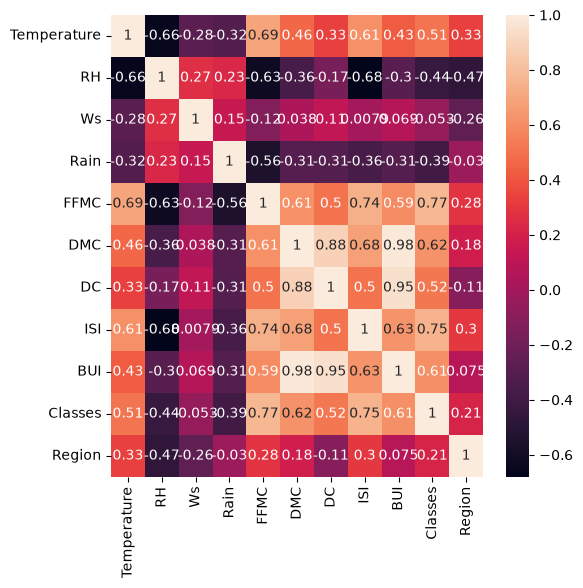

In [18]:
# Check for multi-collinearity
plt.figure(figsize=(6,6))
corr=X_train.corr()
sns.heatmap(corr,annot=True)

In [14]:
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: 
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [ ]:
## threshold--Domain expertise
corr_features=correlation(X_train,0.85)
print(corr_features)

{'BUI', 'DC'}


In [19]:
X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)
X_train.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,ISI,Classes,Region
38,32,68,14,1.4,66.6,7.7,1.1,0,0
86,31,78,18,0.0,85.8,45.6,4.7,1,0
120,26,80,16,1.8,47.4,2.9,0.3,0,0
52,27,66,22,0.4,68.2,10.5,1.8,0,0
30,29,68,19,1.0,59.9,2.5,1.1,0,0


In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Text(0.5, 1.0, 'X_train After Scaling')

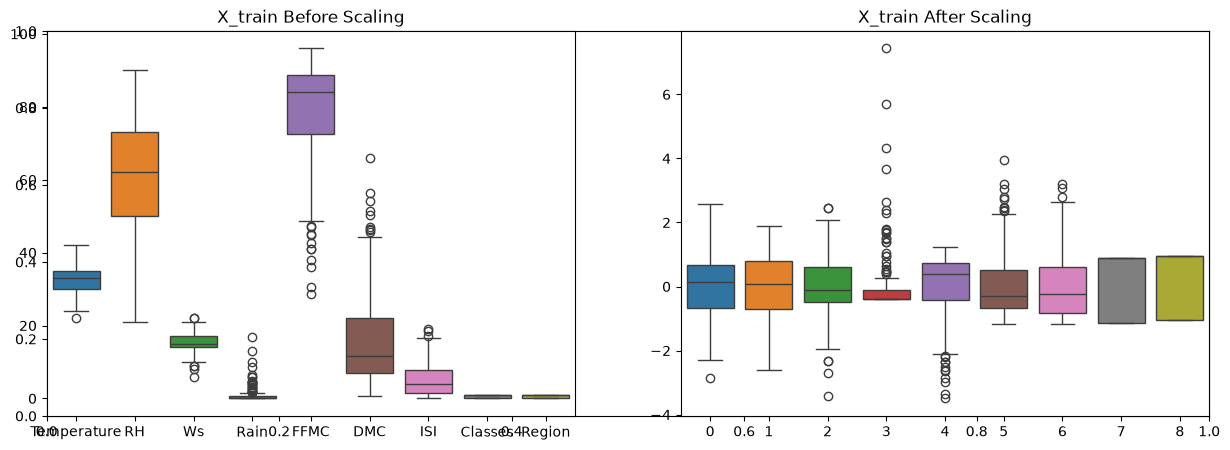

In [22]:
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data= X_train)
plt.title('X_train Before Scaling')
plt.subplot(1, 2, 2)
sns.boxplot(data=X_train_scaled)
plt.title('X_train After Scaling')

Mean absolute error = 0.6993131278959993
R2 score = 0.9732133545455117


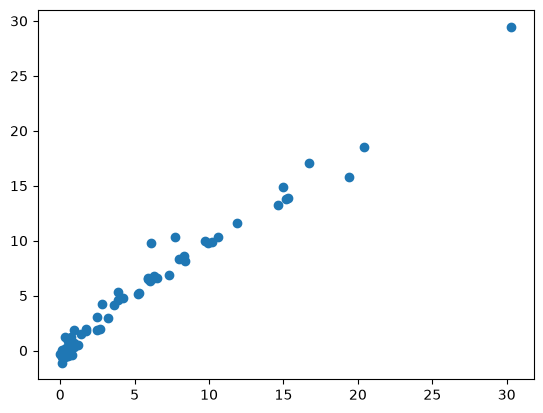

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

linear_reg=LinearRegression()
linear_reg.fit(X_train_scaled,y_train)
y_pred = linear_reg.predict(X_test_scaled)

mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test, y_pred)
print(f"Mean absolute error = {mae}")
print(f"R2 score = {score}")
plt.scatter(y_test,y_pred)

Mean absolute error 1.0936719546515086
R2 Score 0.9415307006848218


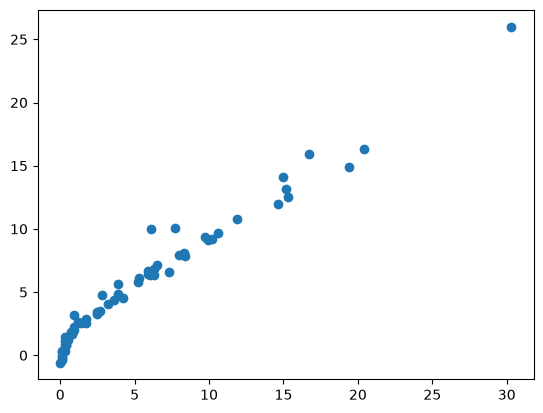

In [26]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
lasso=Lasso()
lasso.fit(X_train_scaled,y_train)
y_pred=lasso.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

In [31]:
from sklearn.linear_model import LassoCV
Lassocv = LassoCV(cv = 5)
Lassocv.fit(X_train,y_train)
print(Lassocv.alpha_)
print(Lassocv.alphas_)
print(len(Lassocv.alphas_))
Lassocv.predict(X_train_scaled)

0.08659963893249609
[86.59963893 80.76311311 75.31994959 70.24363707 65.50945103 61.09433328
 56.9767797  53.13673544 49.55549731 46.21562265 43.10084436 40.19599171
 37.4869164  34.9604237  32.60420815 30.40679364 28.35747752 26.44627844
 24.66388779 23.0016243  21.4513918  20.00563979 18.65732663 17.39988526
 16.22719122 15.13353285 14.11358338 13.1623751  12.27527507 11.44796261
 10.67640825  9.95685407  9.28579543  8.65996389  8.07631131  7.53199496
  7.02436371  6.5509451   6.10943333  5.69767797  5.31367354  4.95554973
  4.62156227  4.31008444  4.01959917  3.74869164  3.49604237  3.26042081
  3.04067936  2.83574775  2.64462784  2.46638878  2.30016243  2.14513918
  2.00056398  1.86573266  1.73998853  1.62271912  1.51335328  1.41135834
  1.31623751  1.22752751  1.14479626  1.06764082  0.99568541  0.92857954
  0.86599639  0.80763113  0.7531995   0.70243637  0.65509451  0.61094333
  0.5697678   0.53136735  0.49555497  0.46215623  0.43100844  0.40195992
  0.37486916  0.34960424  0.326

c:\Users\Code and Debug\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LassoCV was fitted with feature names
  warnings.warn(


array([-0.29634131,  1.47691897, -0.5674266 , -0.05200853, -0.39964009,
       -0.65287414, -0.55982824, -0.37323727,  1.02368024, -0.79336098,
        3.37303298,  0.25049634, -0.51101281,  0.21622136,  0.01401886,
        0.02502577,  0.52699789,  0.52742715, -0.0478172 ,  0.05757185,
        0.78998843,  2.27647092,  1.18567647,  2.70696716,  0.88641234,
       -0.81929733,  1.66579153,  0.97749173, -0.63398987, -1.05240757,
       -1.37536011, -1.0533343 ,  2.25604825, -0.35788679, -1.21864322,
       -0.43375108,  1.07987257, -0.28343038,  2.52592631,  1.43309666,
        2.47666155,  0.83450551, -0.21197876, -0.64454347, -0.18320157,
        0.44932083, -0.61216719,  3.70972653,  1.02693993, -1.07409039,
        2.96024386, -1.27833144,  0.61904701, -0.61040392, -0.15908338,
       -0.15459027, -0.02019669,  0.04461935, -1.37178621, -1.24602004,
       -0.57606837, -1.10425438, -0.97567563, -0.30078558, -1.22524698,
        1.59527432,  0.68227367, -1.25873954,  0.73940658, -0.22

Mean absolute error = 0.7115355480115287
R2 score = 0.9725775211141654


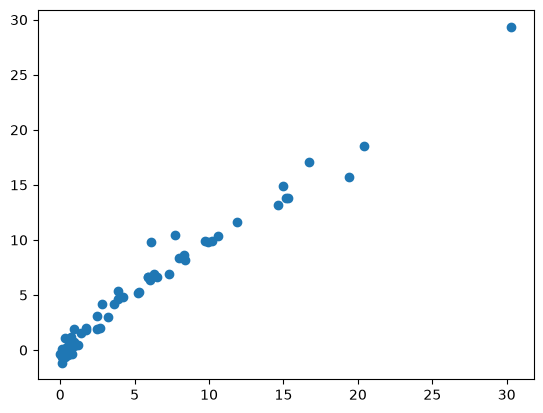

In [24]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

ridge=Ridge()
ridge.fit(X_train_scaled,y_train)
y_pred = ridge.predict(X_test_scaled)

mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test, y_pred)
print(f"Mean absolute error = {mae}")
print(f"R2 score = {score}")
plt.scatter(y_test,y_pred)

Mean absolute error 0.7115355480115287
R2 Score 0.9725775211141654


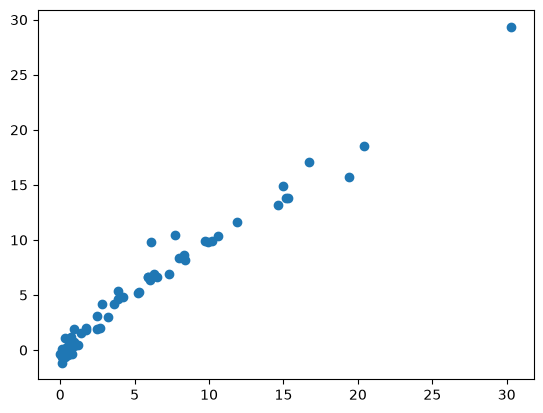

In [32]:
from sklearn.linear_model import RidgeCV
ridgecv=RidgeCV(cv=5)
ridgecv.fit(X_train_scaled,y_train)
y_pred=ridgecv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

Mean absolute error = 1.696411270302396
R2 score = 0.8726273528310866


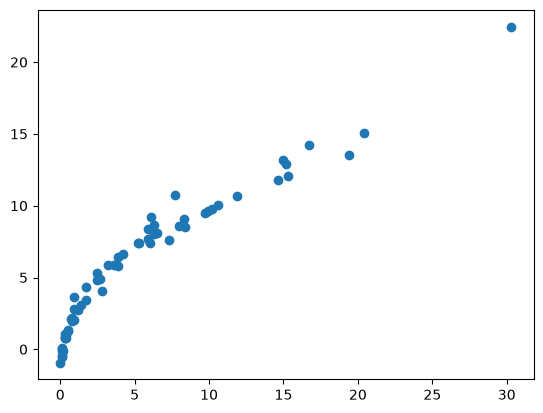

In [25]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, r2_score

elastic_net=ElasticNet()
elastic_net.fit(X_train_scaled,y_train)
y_pred = elastic_net.predict(X_test_scaled)

mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test, y_pred)
print(f"Mean absolute error = {mae}")
print(f"R2 score = {score}")
plt.scatter(y_test,y_pred)

In [33]:
from sklearn.linear_model import ElasticNetCV
elasticcv=ElasticNetCV(cv=5)
elasticcv.fit(X_train_scaled,y_train)


,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"l1_ratio l1_ratio: float or list of float, default=0.5Float between 0 and 1 passed to ElasticNet (scaling betweenl1 and l2 penalties). For ``l1_ratio = 0``the penalty is an L2 penalty. For ``l1_ratio = 1`` it is an L1 penalty.For ``0 < l1_ratio < 1``, the penalty is a combination of L1 and L2This parameter can be a list, in which case the differentvalues are tested by cross-validation and the one giving the bestprediction score is used. Note that a good choice of list ofvalues for l1_ratio is often to put more values close to 1(i.e. Lasso) and less close to 0 (i.e. Ridge), as in ``[.1, .5, .7,.9, .95, .99, 1]``.",0.5
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"alphas alphas: array-like or int, default=100Values of alphas to test along the regularization path, used for each l1_ratio.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`.",100
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"verbose verbose: bool or int, default=0Amount of verbosity.",0
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None


Mean absolute error 0.7461346249829919
R2 Score 0.9708747341937387


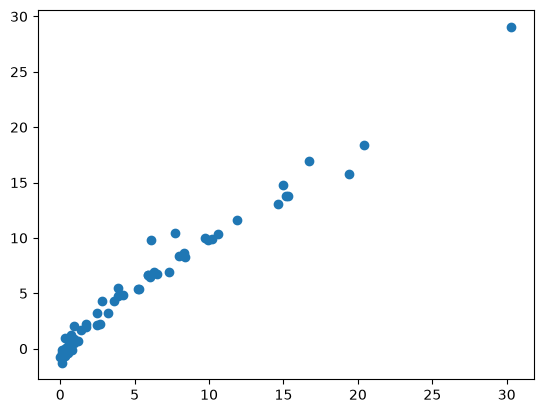

In [34]:
y_pred=elasticcv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

In [35]:
from sklearn.linear_model import LassoCV
Lassocv = LassoCV(cv = 5)
Lassocv.fit(X_train,y_train)

,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"alphas alphas: array-like or int, default=100Values of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`.",100
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as an argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, `X` will be copied; otherwise, it may be overwritten.",True
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"positive positive: bool, default=FalseIf positive, restrict regression coefficients to be positive.",False
